# Genetic Algorithms for Feature Selection in Machine Learning

## Learning Objectives

In this notebook you will learn how a **Genetic Algorithm (GA)** can be used to solve a machine learning optimization problem.

Rather than optimizing the weights of a model, our GA will search for the **best subset of input features** to use when training a classifier.

### Two algorithms are working together

There are two learning processes happening in this notebook:

1. **Logistic Regression** learns the parameters (weights) of a classifier.
2. **The Genetic Algorithm** searches for which features Logistic Regression should use.

The GA never changes how Logistic Regression works. Instead, it repeatedly asks:

> "If Logistic Regression only used this subset of features, how well would it perform?"

The answer becomes the chromosome's **fitness**.

### Why use a Genetic Algorithm?

This dataset contains **30 input features**.

Each feature can either be **used** or **ignored**, which means there are over **2^30 (more than one billion)** possible feature subsets.

Instead of trying every possibility, a Genetic Algorithm intelligently searches this enormous space.

### What you should learn

By the end of this notebook you should be able to explain:

- what a chromosome represents
- how fitness is calculated
- how selection, crossover, and mutation work
- how these operators combine to improve solutions over many generations
- why the test set is evaluated only once at the end


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 6666
rng = np.random.default_rng(RANDOM_SEED)

## 1. Load and split the data

We first hold out a **test set**. We then split the remaining data again to create a **training set** and a **validation set**.

The GA will never see the test labels while it is searching.


In [2]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# First split: keep 20% completely untouched for final testing.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

# Second split: create training and validation sets from the remaining data.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,  # 25% of 80% = 20% of the full dataset
    random_state=RANDOM_SEED,
    stratify=y_train_val,
)

print(f"Training examples:   {len(X_train)}")
print(f"Validation examples: {len(X_val)}")
print(f"Test examples:       {len(X_test)}")
print(f"Number of features:  {X.shape[1]}")


Training examples:   341
Validation examples: 114
Test examples:       114
Number of features:  30


## 2. Define the machine-learning model

We use logistic regression as the model that the GA is trying to help.

`StandardScaler` standardizes the selected features before logistic regression is trained. Using a pipeline keeps those two steps together.


In [3]:
def make_model():
    """Create a fresh logistic regression model."""
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    )


Before using the GA, let's establish a simple baseline: train the model using **all 30 features** and measure validation accuracy.


In [4]:
baseline_model = make_model()
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_val)
baseline_accuracy = accuracy_score(y_val, baseline_predictions)

print(f"Validation accuracy using all features: {baseline_accuracy:.3f}")


Validation accuracy using all features: 0.974


## 3. Represent a solution: the chromosome

Each chromosome has one Boolean value per feature. We start with random chromosomes where each feature has a configurable probability of being included.


### GA Vocabulary

| Term | Meaning in this notebook |
|------|--------------------------|
| Gene | One feature (selected or not) |
| Chromosome | One complete feature subset |
| Population | A collection of chromosomes |
| Fitness | Validation accuracy |
| Selection | Choose parents with better fitness |
| Crossover | Combine two parents |
| Mutation | Randomly flip genes |
| Generation | One cycle of evolution |

Example chromosome:

```
Feature:      radius texture perimeter area
Chromosome:      1       0        1      0
```

This chromosome tells the ML model to use **radius** and **perimeter**, while ignoring **texture** and **area**.


In [5]:
def initialize_population(population_size, n_features, include_probability=0.5):
    """Create a population of random feature-selection chromosomes."""
    population = rng.random((population_size, n_features)) < include_probability

    # A model cannot be trained with zero features, so repair any empty chromosome.
    for chromosome in population:
        if not chromosome.any():
            chromosome[rng.integers(n_features)] = True

    return population


## 4. Fitness: train an ML model and score it

This is the most important connection between the GA and machine learning.

For each chromosome, we select its active features, train logistic regression on the **training set**, and evaluate accuracy on the **validation set**. That validation accuracy is the fitness score.


The fitness function is the **heart of the genetic algorithm**.

For every chromosome we perform the following steps:

```
Chromosome
      ↓
Select the chosen features
      ↓
Train Logistic Regression
      ↓
Predict the validation data
      ↓
Compute validation accuracy
      ↓
Fitness score
```

Notice that the GA never learns directly. It simply compares fitness scores and keeps better solutions.


In [6]:
def fitness(chromosome, X_train, y_train, X_val, y_val):
    """Return validation accuracy for one feature-selection chromosome."""
    selected = chromosome

    model = make_model()
    model.fit(X_train[:, selected], y_train)
    predictions = model.predict(X_val[:, selected])

    return accuracy_score(y_val, predictions)


def evaluate_population(population, X_train, y_train, X_val, y_val):
    """Compute one fitness score for every chromosome in the population."""
    return np.array([
        fitness(chromosome, X_train, y_train, X_val, y_val)
        for chromosome in population
    ])


## 5. Selection

We use **tournament selection** because it is easy to understand and modify:

1. Randomly choose a few chromosomes.
2. Compare their fitness scores.
3. Select the best one as a parent.

Better chromosomes are more likely to become parents, but weaker chromosomes can still be selected if they happen to enter a different tournament.


In [7]:
def select_parent(population, scores, tournament_size=3):
    """Choose one parent using tournament selection."""
    competitors = rng.choice(len(population), size=tournament_size, replace=False)
    winner = competitors[np.argmax(scores[competitors])]
    return population[winner].copy()


## 6. Crossover

Two parents create one child. We use **one-point crossover**: choose a random split point, take the beginning from parent 1, and the end from parent 2.


In [8]:
def crossover(parent1, parent2):
    """Create one child using one-point crossover."""
    n_features = len(parent1)
    point = rng.integers(1, n_features)

    return np.concatenate([
        parent1[:point],
        parent2[point:],
    ])


## 7. Mutation

Mutation flips individual feature choices with a small probability.

A `True` may become `False`, or a `False` may become `True`. Mutation helps the population continue exploring new solutions.


In [9]:
def mutate(chromosome, mutation_rate):
    """Randomly flip genes in a chromosome."""
    child = chromosome.copy()
    mutation_mask = rng.random(len(child)) < mutation_rate
    child[mutation_mask] = ~child[mutation_mask]

    # Repair the chromosome if mutation turned every feature off.
    if not child.any():
        child[rng.integers(len(child))] = True

    return child


## 8. Put the GA together

Each generation does four things:

1. **Evaluate** every chromosome.
2. **Keep** the best chromosome unchanged (elitism).
3. **Select parents** and create children with crossover.
4. **Mutate** the children.

We also record the minimum, mean, and maximum fitness so we can watch the population change over time.


The `run_ga()` function is almost a direct translation of this algorithm:

```text
Create an initial random population

Repeat for each generation:

    Evaluate every chromosome

    Remember the best solution

    Keep the best chromosome (elitism)

    While the new population is not full:
        Select two parents
        Perform crossover
        Mutate the child
        Add the child to the new population

Return the best chromosome found
```


In [10]:
def run_ga(
    X_train,
    y_train,
    X_val,
    y_val,
    population_size=30,
    generations=30,
    mutation_rate=0.05,
):
    """Run a simple genetic algorithm for feature selection."""
    n_features = X_train.shape[1]
    population = initialize_population(population_size, n_features)

    history = {"min": [], "mean": [], "max": []}
    best_chromosome = None
    best_score = -np.inf

    for generation in range(generations):
        scores = evaluate_population(population, X_train, y_train, X_val, y_val)

        # Record statistics for this generation.
        history["min"].append(scores.min())
        history["mean"].append(scores.mean())
        history["max"].append(scores.max())

        # Remember the best solution seen so far.
        generation_best = np.argmax(scores)
        if scores[generation_best] > best_score:
            best_score = scores[generation_best]
            best_chromosome = population[generation_best].copy()

        # Elitism: the best chromosome survives unchanged.
        next_population = [population[generation_best].copy()]

        # Create the rest of the next generation.
        while len(next_population) < population_size:
            parent1 = select_parent(population, scores)
            parent2 = select_parent(population, scores)
            child = crossover(parent1, parent2)
            child = mutate(child, mutation_rate)
            next_population.append(child)

        population = np.array(next_population)

    return best_chromosome, best_score, history


## 9. Run the genetic algorithm

These are the main settings students should experiment with first.


In [11]:
POPULATION_SIZE = 30
GENERATIONS = 30
MUTATION_RATE = 0.05

best_chromosome, best_validation_accuracy, history = run_ga(
    X_train,
    y_train,
    X_val,
    y_val,
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    mutation_rate=MUTATION_RATE,
)

selected_features = feature_names[best_chromosome]

print(f"Best validation accuracy: {best_validation_accuracy:.3f}")
print(f"Features selected: {best_chromosome.sum()} / {len(best_chromosome)}")
print()
print("Selected features:")
for name in selected_features:
    print(f"  - {name}")


Best validation accuracy: 0.982
Features selected: 16 / 30

Selected features:
  - mean radius
  - mean texture
  - mean perimeter
  - mean smoothness
  - mean compactness
  - mean concavity
  - mean concave points
  - mean symmetry
  - perimeter error
  - fractal dimension error
  - worst texture
  - worst area
  - worst smoothness
  - worst compactness
  - worst concavity
  - worst concave points


## 10. Watch evolution happen

The maximum line shows the best chromosome in each generation. The mean shows how the population as a whole is doing.


### What should you expect?

Early generations are mostly random.

As evolution progresses:

- the **best fitness** should improve or stay the same,
- the **average fitness** should gradually increase,
- eventually progress slows as the population converges.

Because the algorithm is random, your graph will not exactly match someone else's.


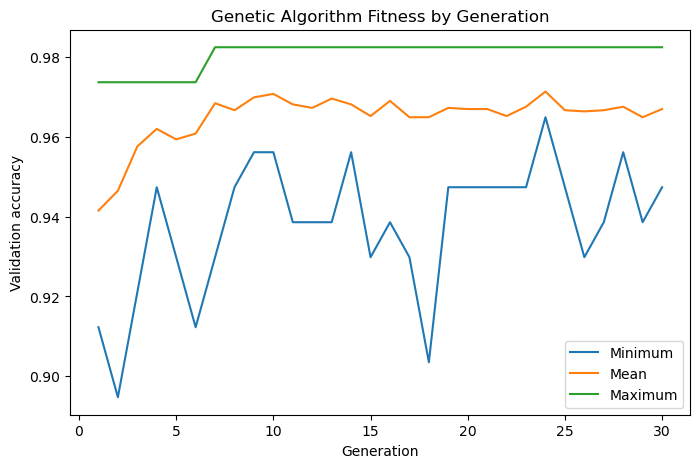

In [12]:
generations_axis = np.arange(1, GENERATIONS + 1)

plt.figure(figsize=(8, 5))
plt.plot(generations_axis, history["min"], label="Minimum")
plt.plot(generations_axis, history["mean"], label="Mean")
plt.plot(generations_axis, history["max"], label="Maximum")
plt.xlabel("Generation")
plt.ylabel("Validation accuracy")
plt.title("Genetic Algorithm Fitness by Generation")
plt.legend()
plt.show()


## 11. Final evaluation on the test set

The GA has finished searching, so now we can finally use the untouched test set.

We retrain logistic regression using the selected features and all of the data that was available during development (training + validation). Then we evaluate that final model on the test set **once**.


In [13]:
X_train_final = np.vstack([X_train, X_val])
y_train_final = np.concatenate([y_train, y_val])

final_model = make_model()
final_model.fit(X_train_final[:, best_chromosome], y_train_final)
test_predictions = final_model.predict(X_test[:, best_chromosome])
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Selected features: {best_chromosome.sum()} / {len(best_chromosome)}")
print(f"Final test accuracy: {test_accuracy:.3f}")


Selected features: 16 / 30
Final test accuracy: 0.947


## What just happened?

The Genetic Algorithm searched through many possible feature subsets.

For each candidate solution it:

1. Selected the requested features.
2. Trained a Logistic Regression model.
3. Measured validation accuracy.
4. Used that accuracy as the chromosome's fitness.
5. Created new generations using selection, crossover, and mutation.

The final chromosome is **not guaranteed to be the globally optimal feature subset**.
It is simply the best solution discovered during this search.


# Questions and experiments

Now that the basic GA works, try changing **one thing at a time** and explain what happens.

- Change the population size. Does a larger population help?
- Change the mutation rate. What happens if mutation is extremely small or extremely large?
- Change tournament size in `select_parent`. How does stronger selection pressure affect the population?
- Replace one-point crossover with two-point or uniform crossover.
- Remove elitism. Can the best score decrease from one generation to the next?
- Change the fitness function so that it rewards accuracy **and** penalizes using too many features.
- Run the algorithm with a different random seed. How stable are the selected features?

## A useful extension

Right now, fitness is based only on predictive accuracy. Suppose we prefer a simpler model that uses fewer features. One possible objective is:

```text
fitness = validation_accuracy - penalty_for_number_of_features
```

That small change turns this into a multi-objective-style tradeoff between **performance** and **simplicity** and is a good next experiment after understanding the basic example.
